# Wczytanie danych

In [ ]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/Dane/dane/manchester.csv", delimiter=";")
data.head()

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,157612,New attic space/single & Dble room,"The loft space is a small but cosy, private an...",There is a public park within easy walking dis...,757016,Margaret,29.06.2011,"Salford, United Kingdom",Hi we are Tom and Margaret. retired Engineer a...,within a few hours,...,4.92,4.68,4.88,NaN,f,1,1,0,0,1.04
1,283495,En-suite room in detached house,NaN,The suburbaness of it all but 2 minutes from t...,1476718,Alison,6.12.2011,"Manchester, United Kingdom",NaN,NaN,...,5.00,4.80,5.00,NaN,f,1,0,1,0,0.08
2,310742,Nice room 10 minutes walk from town,NaN,NaN,1603652,Francisca,13.01.2012,"Manchester, United Kingdom","Hi , I am a spanish girl who really likes bein...",within a day,...,4.86,4.81,4.65,NaN,t,1,0,1,0,0.39
3,332580,**ELEGANT STAY** CENTRAL MANCHESTER,"An Elegant Stay right into the CITY CENTRE, in...",You will be staying in the trendy Northern Qua...,1694961,Alain,3.02.2012,"Manchester, United Kingdom",Hi there :) I am a friendly guy with some nice...,within an hour,...,4.94,4.88,4.82,NaN,f,4,3,1,0,2.23
4,360142,Light double room next to bathroom,Lovely bright room at rear of house. Double be...,It's a proper cosmopolitan inner city neighbou...,1821587,Ekua,27.02.2012,"Manchester, United Kingdom","Family home in Manchester, but now my 2 grown ...",within a few hours,...,4.88,4.51,4.75,NaN,f,2,0,2,0,0.31


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7418 entries, 0 to 7417
Data columns (total 68 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            7418 non-null   object 
 1   name                                          7418 non-null   object 
 2   description                                   7268 non-null   object 
 3   neighborhood_overview                         2752 non-null   object 
 4   host_id                                       7418 non-null   int64  
 5   host_name                                     7415 non-null   object 
 6   host_since                                    7415 non-null   object 
 7   host_location                                 4872 non-null   object 
 8   host_about                                    3454 non-null   object 
 9   host_response_time                            6666 non-null   o

In [ ]:
data = data.drop(columns=['minimum_minimum_nights'])
data = data.drop(columns=['maximum_minimum_nights'])
data = data.drop(columns=['minimum_maximum_nights'])
data = data.drop(columns=['maximum_maximum_nights'])
data = data.drop(columns=['minimum_nights_avg_ntm'])
data = data.drop(columns=['maximum_nights_avg_ntm'])

In [ ]:
data['id'].count()

np.int64(7418)

In [ ]:
data = data.drop_duplicates(subset=['id'])

In [ ]:
data['id'].count()

np.int64(6920)

# Brakujące wartości

In [ ]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [ ]:
missing_data[:25]

,missing value,percentage
license,6920,100.000000
host_neighbourhood,6617,95.621387
neighborhood_overview,4320,62.427746
host_about,3693,53.367052
host_location,2307,33.338150
review_scores_cleanliness,1211,17.500000
review_scores_accuracy,1210,17.485549
review_scores_checkin,1210,17.485549
reviews_per_month,1210,17.485549
first_review,1210,17.485549


In [ ]:
data = data.drop(columns=['license'])
data = data.drop(columns=['host_neighbourhood'])
data = data.drop(columns=['neighborhood_overview'])

Cena jest kluczowa do naszego projektu, trzeba usunąć wiersze które jej nie mają

In [ ]:
data = data[data['price'].notna()]

In [ ]:
mask = data.isnull()
total = mask.sum()
per = 100*mask.mean()
missing_data = pd.concat([total, per], axis=1,keys=['missing value', 'percentage'])
missing_data.sort_values(by='percentage', ascending=False, inplace=True)

In [ ]:
missing_data[:15]

,missing value,percentage
host_about,3254,53.152565
host_location,2061,33.665469
review_scores_cleanliness,1075,17.559621
review_scores_checkin,1074,17.543287
review_scores_value,1074,17.543287
review_scores_rating,1074,17.543287
last_review,1074,17.543287
review_scores_communication,1074,17.543287
review_scores_accuracy,1074,17.543287
review_scores_location,1074,17.543287


In [ ]:
data['bedrooms'] = data['bedrooms'].fillna(data['bedrooms'].median())
data['beds'] = data['beds'].fillna(data['beds'].median())

# Wartości odstające

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
host_id,6122.0,3.277174e+08,2.293266e+08,299111.000000,9.682249e+07,3.285289e+08,5.289064e+08,7.205524e+08
host_listings_count,6119.0,3.305442e+01,1.459387e+02,1.000000,1.000000e+00,3.000000e+00,1.100000e+01,1.815000e+03
host_total_listings_count,6119.0,8.082726e+01,6.118081e+02,1.000000,2.000000e+00,4.000000e+00,1.500000e+01,8.774000e+03
latitude,6122.0,5.347856e+01,4.834913e-02,53.335938,5.345477e+01,5.347875e+01,5.349568e+01,5.366456e+01
longitude,6122.0,-2.254698e+00,1.028391e-01,-2.716225,-2.284053e+00,-2.244170e+00,-2.211245e+00,-1.976890e+00
accommodates,6122.0,4.020745e+00,2.653932e+00,1.000000,2.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01
bathrooms,6114.0,1.432532e+00,1.065914e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+01
bedrooms,6122.0,1.866057e+00,1.488625e+00,0.000000,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+01
beds,6122.0,2.422248e+00,2.178428e+00,0.000000,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+01
minimum_nights,6122.0,4.220680e+00,1.675992e+01,1.000000,1.000000e+00,2.000000e+00,2.000000e+00,6.000000e+02


## Szerokość i długość geograficzna

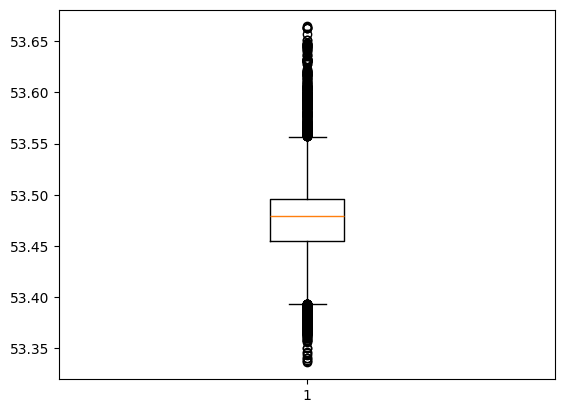

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(x=data['latitude'])
plt.show()

In [ ]:
import numpy as np
q1 = np.quantile(data['latitude'], 0.25)
q3 = np.quantile(data['latitude'], 0.75)
iqr = q3-q1
upper_lim = q3+(3*iqr)
lower_lim = q1-(3*iqr)

In [ ]:
outliers_1 = data[(data['latitude'] > upper_lim) | (data['latitude'] < lower_lim)]
outliers_1

,id,name,description,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
5,391704,bright dble room,NaN,1958935,Janet,18.03.2012,"Littleborough, United Kingdom","I ENJOY SPENDING TIME WITH FRIENDS,SALSA DANCI...",within an hour,67%,...,5.00,5.00,5.00,5.00,f,1,0,1,0,0.01
70,5865430,"""Cart Shed Cottage""","Newly Converted Cottage, double ensuite with l...",30456673,Stephanie,2.04.2015,"Milnrow, United Kingdom",NaN,within an hour,80%,...,4.87,4.85,4.73,4.90,f,1,1,0,0,1.47
202,15336155,"Single room, use of facilities, Bromley Cross",Single room situated in Bromley Cross in the N...,97722975,Sarah,3.10.2016,"Bolton, United Kingdom",NaN,within a few hours,100%,...,4.92,4.94,4.78,4.90,f,1,0,1,0,1.11
235,17261329,"103 Whalley Road, Ramsbottom",BEAUTIFUL 4 BEDROOM 2 BATHROOM HOUSE***ACCOMMO...,116360477,Lavish Lettings Ltd,14.02.2017,United Kingdom,Welcome to Lavish Lettings Ltd! We offer luxur...,within an hour,100%,...,4.69,4.68,4.48,4.44,t,12,12,0,0,1.45
446,27771202,Cosy Studio for two Ramsbottom,This is a relaxing completely self-contained s...,201109002,Sarah,9.07.2018,"Bury, United Kingdom","Female, white",within an hour,100%,...,4.98,4.98,4.93,4.95,f,1,1,0,0,2.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,"1,45228E+18",4BR - Contractor/Family Home,"Spacious and modern 4-bedroom home, ideal for ...",169832579,Morgan,25.01.2018,"Manchester, United Kingdom",NaN,within an hour,98%,...,NaN,NaN,NaN,NaN,t,8,8,0,0,NaN
6640,"1,45719E+18",Double story Suite in Rochdale,"Located in the heart of Rochdale, this stylish...",690733308,Deen,18.04.2025,NaN,NaN,within an hour,100%,...,4.71,5.00,4.47,4.59,t,1,1,0,0,7.08
6789,"1,46747E+18",Shepherd's Hut in Greater Manchester,Take a break and unwind at this idyllic Shephe...,463841257,Jill,12.06.2022,NaN,NaN,within an hour,100%,...,5.00,5.00,4.86,5.00,f,1,1,0,0,4.47
6799,"1,468E+18",The Nook Country Cottage Hot Tub Garden Open Fire,A getaway/countryside break in a self contain ...,694179151,Samuel,7.05.2025,NaN,NaN,within an hour,96%,...,4.88,4.81,4.69,4.75,t,1,1,0,0,8.57


In [ ]:
q1 = np.quantile(data['longitude'], 0.25)
q3 = np.quantile(data['longitude'], 0.75)
iqr = q3-q1
upper_lim = q3+(2.75*iqr)
lower_lim = q1-(2.75*iqr)

In [ ]:
outliers_2 = data[(data['longitude'] > upper_lim) | (data['longitude'] < lower_lim)]
outliers_2['neighbourhood_cleansed']

,neighbourhood_cleansed
83,Wigan District
182,Wigan District
219,Oldham District
223,Wigan District
224,Wigan District
...,...
7326,Wigan District
7391,Oldham District
7392,Bolton District
7395,Wigan District


## Mininum/maximum nights

In [ ]:
q1 = np.quantile(data['minimum_nights'], 0.25)
q3 = np.quantile(data['minimum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(50*iqr)
lower_lim = q1-(50*iqr)

In [ ]:
outliers_3 = data[(data['minimum_nights'] > upper_lim) | (data['minimum_nights'] < lower_lim)]
outliers_3['minimum_nights']

,minimum_nights
1,100
2,180
25,69
37,69
204,280
212,79
249,365
627,69
780,365
849,300


In [ ]:
data = data[~((data['minimum_nights'] > upper_lim) | (data['minimum_nights'] < lower_lim))]

In [ ]:
q1 = np.quantile(data['maximum_nights'], 0.25)
q3 = np.quantile(data['maximum_nights'], 0.75)
iqr = q3-q1
upper_lim = q3+(5*iqr)
lower_lim = q1-(5*iqr)

In [ ]:
outliers_4 = data[(data['maximum_nights'] > upper_lim) | (data['maximum_nights'] < lower_lim)]
outliers_4['maximum_nights'].unique()

array([  28,  730,   30, 1125,  120,   14,   35,   18,  180,   12,   40,
        100,  150,  300,  400,    2,   31,   65,    9,   50,  200,   60,
          7,    3,  360,  356,   85,  700,   90,   20,  199,   45,   99,
         10,   21,   29,  112,   70,   81,   56,    5,  729,   93,   27,
         84,   92,   89, 1000,  364, 1120,  253,  250,   15,  548,  999,
        152,   26,    6,   42,  210, 1124,  500,  140,  349,  267,  125,
         95,  160,  720,   62,  185,    1,  295,    4,   32,  172,  600,
         25,  173,  153,   36,   16,  353,    8,  182,  280,  209,  186,
        193,  239,  196,   61,  213,  240,  226,  357,  161,  197,  164,
        265,  337,   34,   22,  238,  247,  202,   75,  277,  151,  178,
        179,   91,  246,  181,   11,   80,  101,   33,  142,  325,   57,
        116,  128,  366,  331,  344,  136,  690,  258,  221])

In [ ]:
#data = data[~((data['maximum_nights'] > upper_lim) | (data['maximum_nights'] < lower_lim))]

## Łazienki i sypialnie

In [ ]:
q1 = data['bathrooms'].quantile(0.25)
q3 = data['bathrooms'].quantile(0.75)
iqr = q3-q1
upper_lim = q3+(7*iqr)
lower_lim = q1-(7*iqr)

In [ ]:
outliers_5 = data[(data['bathrooms'] > upper_lim) | (data['bathrooms'] < lower_lim)]
outliers_5['bathrooms'].unique()

array([27. , 22.5, 10. , 15. , 19. , 50. ])

In [ ]:
outliers_5['bedrooms']

,bedrooms
999,26.0
1038,22.0
3793,5.0
4151,50.0
4261,9.0
6134,50.0


In [ ]:
data = data[~((data['bathrooms'] > upper_lim) | (data['bathrooms'] < lower_lim))]

In [ ]:
q1 = data['bedrooms'].quantile(0.25)
q3 = data['bedrooms'].quantile(0.75)
iqr = q3-q1
upper_lim = q3+(5*iqr)
lower_lim = q1-(5*iqr)

In [ ]:
outliers_5 = data[(data['bedrooms'] > upper_lim) | (data['bedrooms'] < lower_lim)]
outliers_5['bedrooms'].unique()

array([8., 9.])

In [ ]:
#data = data[~((data['bedrooms'] > upper_lim) | (data['bedrooms'] < lower_lim))]

# Ammenities

In [ ]:
czyste_amenities = data['amenities'].str.replace('", "', '|', regex=False)
czyste_amenities = czyste_amenities.str.replace('[', '', regex=False)
czyste_amenities = czyste_amenities.str.replace(']', '', regex=False)
czyste_amenities = czyste_amenities.str.replace('"', '', regex=False)

amenities_df = czyste_amenities.str.get_dummies(sep='|')
amenities_df.insert(0, 'id', data['id'])
amenities_df.head()

,id,2 plate induction hob induction stove,Neff stainless steel single oven,\u2018Ruark\u2019 deluxe Bluetooth radio Bluetooth sound system,. body soap,. oven,. refrigerator,. shampoo,"108 inch HDTV with Netflix, premium cable",16 inch TV,...,Zanussi oven,Zanussi refrigerator,Zanussi single oven,Zanussi stainless steel double oven,Zanussi stainless steel electric stove,Zanussi stainless steel oven,Zanussi stainless steel single oven,Zanussi stove,Zanuzzi refrigerator,Zanuzzi stainless steel oven
0,157612,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,360142,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,391704,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,412687,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,503513,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
columns_to_drop = []
for col in amenities_df.columns:
    if col != 'id' and amenities_df[col].sum() < 100:
        columns_to_drop.append(col)

amenities_filtered_manchester = amenities_df.drop(columns=columns_to_drop)
print(f"Dropped {len(columns_to_drop)} columns.")
amenities_filtered_manchester.head()

Dropped 1790 columns.


,id,Air conditioning,BBQ grill,Backyard,Baking sheet,Barbecue utensils,Bathtub,Bed linens,Bidet,Blender,...,Stove,TV,TV with standard cable,Toaster,Trash compactor,Washer,Waterfront,Wifi,Window guards,Wine glasses
0,157612,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,1
4,360142,0,0,0,0,0,1,1,0,1,...,1,0,0,1,0,1,0,1,0,1
5,391704,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,412687,0,0,0,1,0,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0
7,503513,0,0,0,0,0,0,1,0,1,...,0,1,0,1,0,1,0,1,0,0


In [ ]:
amenities_filtered_manchester.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6068 entries, 0 to 7417
Columns: 133 entries, id to Wine glasses
dtypes: int64(132), object(1)
memory usage: 6.2+ MB


In [ ]:
amenities_filtered_manchester.to_csv('amenities_filtered_manchester.csv', index=False)

# Konwersja typów

In [ ]:
data['price'] = data['price'].str.replace(',', '', regex=False)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = data['price'].astype(float)

In [ ]:
data['price']

,price
0,58.0
4,45.0
5,25.0
6,83.0
7,159.0
...,...
7413,96.0
7414,117.0
7415,138.0
7416,108.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6068 entries, 0 to 7417
Data columns (total 59 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6068 non-null   object 
 1   name                                          6068 non-null   object 
 2   description                                   5946 non-null   object 
 3   host_id                                       6068 non-null   int64  
 4   host_name                                     6065 non-null   object 
 5   host_since                                    6065 non-null   object 
 6   host_location                                 4020 non-null   object 
 7   host_about                                    2843 non-null   object 
 8   host_response_time                            5621 non-null   object 
 9   host_response_rate                            5621 non-null   object

In [ ]:
data = data.drop(columns=['amenities'])

In [ ]:
data['host_response_rate'].unique()

array(['100%', '67%', '70%', '90%', '75%', '86%', nan, '20%', '80%',
       '85%', '0%', '92%', '98%', '88%', '99%', '36%', '96%', '97%',
       '83%', '50%', '87%', '13%', '73%', '40%', '89%', '79%', '14%',
       '82%', '94%', '25%', '77%', '64%', '84%', '95%', '60%', '71%',
       '17%', '10%', '76%', '81%', '93%', '91%', '33%', '57%', '9%',
       '38%', '66%', '42%', '22%', '43%', '63%', '29%', '5%', '69%',
       '58%', '6%', '47%', '11%', '55%', '30%', '48%', '72%', '32%', '8%',
       '78%', '74%'], dtype=object)

In [ ]:
data['host_response_rate'] = data['host_response_rate'].str.replace('%', '', regex=False).astype(float)
data['host_response_rate'] = data['host_response_rate'].apply(lambda x: x/100)

In [ ]:
data['host_response_rate'].fillna(0, inplace=True)

/tmp/ipykernel_733/3073513857.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['host_response_rate'].fillna(0, inplace=True)


In [ ]:
data['host_acceptance_rate'] = data['host_acceptance_rate'].str.replace('%', '', regex=False).astype(float)
data['host_acceptance_rate'] = data['host_acceptance_rate'].apply(lambda x: x/100)

In [ ]:
data['host_acceptance_rate'].fillna(0, inplace=True)
data['host_acceptance_rate'].unique()

/tmp/ipykernel_733/1208224072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['host_acceptance_rate'].fillna(0, inplace=True)


array([0.81, 0.87, 0.  , 1.  , 0.92, 0.98, 0.11, 0.75, 0.95, 0.5 , 0.91,
       0.83, 0.6 , 0.7 , 0.93, 0.96, 0.57, 0.71, 0.86, 0.85, 0.99, 0.97,
       0.8 , 0.67, 0.06, 0.55, 0.14, 0.51, 0.78, 0.94, 0.27, 0.33, 0.84,
       0.9 , 0.73, 0.41, 0.82, 0.88, 0.77, 0.43, 0.1 , 0.2 , 0.72, 0.39,
       0.49, 0.29, 0.56, 0.21, 0.07, 0.89, 0.59, 0.64, 0.3 , 0.62, 0.58,
       0.46, 0.48, 0.23, 0.74, 0.79, 0.17, 0.25, 0.53, 0.4 , 0.44, 0.04,
       0.47, 0.63, 0.69, 0.65, 0.68, 0.76, 0.24, 0.45, 0.22, 0.36, 0.16,
       0.52, 0.26, 0.05, 0.08, 0.37, 0.13, 0.54, 0.35, 0.09, 0.61, 0.32,
       0.18, 0.31, 0.38, 0.42, 0.34, 0.12, 0.66, 0.15])

In [ ]:
data['host_identity_verified'].unique()

array(['t', 'f', nan], dtype=object)

In [ ]:
cols_to_convert = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified','has_availability','instant_bookable']

In [ ]:
for col in cols_to_convert:
    data[col] = data[col].replace({'t': True, 'f': False, 'True': True, 'False': False, 'TRUE': True, 'FALSE': False})
    data[col] = data[col].fillna(False)
    data[col] = data[col].astype(int)

/tmp/ipykernel_733/4011864632.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(False)
/tmp/ipykernel_733/4011864632.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].fillna(False)
/tmp/ipykernel_733/4011864632.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].

In [ ]:
data['instant_bookable'].unique()

array([0, 1])

In [ ]:
data['id'] = data['id'].astype(str)
data['host_id'] = data['host_id'].astype(str)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6068 entries, 0 to 7417
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6068 non-null   object 
 1   name                                          6068 non-null   object 
 2   description                                   5946 non-null   object 
 3   host_id                                       6068 non-null   object 
 4   host_name                                     6065 non-null   object 
 5   host_since                                    6065 non-null   object 
 6   host_location                                 4020 non-null   object 
 7   host_about                                    2843 non-null   object 
 8   host_response_time                            5621 non-null   object 
 9   host_response_rate                            6068 non-null   float6

In [ ]:
data = data.replace(to_replace=[r'\r\n', r'\n', r'\r'], value=' ', regex=True)

In [ ]:
numeryczne = data.select_dtypes(include='number')
numeryczne.head()

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,latitude,longitude,accommodates,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1.00,0.81,1,1.0,3.0,1,1,53.501530,-2.262490,3,...,4.96,4.92,4.68,4.88,0,1,1,0,0,1.04
4,1.00,0.87,0,2.0,3.0,1,1,53.454660,-2.235420,2,...,4.92,4.88,4.51,4.75,0,2,0,2,0,0.31
5,0.67,0.00,0,1.0,6.0,1,0,53.657250,-2.085980,2,...,5.00,5.00,5.00,5.00,0,1,0,1,0,0.01
6,1.00,1.00,1,1.0,1.0,1,1,53.393000,-2.349040,2,...,4.99,4.99,4.96,4.95,0,1,1,0,0,2.90
7,1.00,1.00,1,1.0,10.0,1,0,53.484653,-2.196015,4,...,4.86,4.93,4.86,4.66,1,1,1,0,0,0.37


In [ ]:
for col in numeryczne:
  data[col] = data[col].astype(str)
  data[col] = data[col].str.replace('.', ',', regex=False)

In [ ]:
data['host_response_rate'].head()

,host_response_rate
0,"1,0"
4,"1,0"
5,"0,67"
6,"1,0"
7,"1,0"


In [ ]:
data['id'].count()

np.int64(6068)

In [ ]:
len(data['id'].unique())

6068

In [ ]:
data.to_csv('manchester_cleaned.csv', index=False)